In [1]:
import pandas as pd

In [33]:
df = pd.read_csv('data.csv')
df.drop(columns=["subject_id"," PULSE","Time [s]"],inplace=True)
df.rename(columns={" RESP":"RR"},inplace=True)
df.rename(columns={" HR":"HR"},inplace=True)
df.rename(columns={" SpO2":"SpO2"},inplace=True)
df.columns ##tells exactly how the columns are named 
df = df.dropna()
df.info

<bound method DataFrame.info of          HR    RR   SpO2
0      94.0  25.0   97.0
1      94.0  25.0   97.0
2      94.0  25.0   97.0
3      92.0  26.0   97.0
4      93.0  26.0   97.0
...     ...   ...    ...
25488  92.0  18.0  100.0
25489  90.0  19.0  100.0
25490  97.0  19.0  100.0
25491  99.0  19.0  100.0
25492  94.0  19.0  100.0

[25208 rows x 3 columns]>

In [34]:
df.columns

Index(['HR', 'RR', 'SpO2'], dtype='object')

In [37]:
# Supprimer valeurs aberrantes (optionnel mais recommandé)
df = df[(df['HR'] > 30) & (df['HR'] < 200)]
df = df[(df['RR'] > 5) & (df['RR'] < 40)]
df = df[(df['SpO2'] > 70) & (df['SpO2'] <= 100)]
df.info

df = df.reset_index(drop=True)
print("Data cleaned:", df.shape)

Data cleaned: (24975, 3)


## NORMALISATION

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Modèle Isolation Forest

In [39]:
from sklearn.ensemble import IsolationForest

# contamination = % estimé d'anomalies (à ajuster)
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

model.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

## Prédiction des anomalies

In [40]:
# Prédiction (-1 = anomalie, 1 = normal)
df['anomaly'] = model.predict(X_scaled)

# Score d'anomalie (plus bas = plus anomal)
df['score'] = model.decision_function(X_scaled)

# Convertir en 0 (normal) / 1 (anomalie)
df['anomaly_label'] = df['anomaly'].apply(lambda x: 1 if x == -1 else 0)

df.head(100)

,HR,RR,SpO2,anomaly,score,anomaly_label
0,94.0,25.0,97.0,1,0.034015,0
1,94.0,25.0,97.0,1,0.034015,0
2,94.0,25.0,97.0,1,0.034015,0
3,92.0,26.0,97.0,1,0.004911,0
4,93.0,26.0,97.0,1,0.005041,0
...,...,...,...,...,...,...
95,92.0,23.0,97.0,1,0.087889,0
96,93.0,23.0,97.0,1,0.090749,0
97,93.0,23.0,97.0,1,0.090749,0
98,93.0,23.0,97.0,1,0.090749,0


In [42]:
anomaly_df = df[df['anomaly'] == -1]
anomaly_df.head()

,HR,RR,SpO2,anomaly,score,anomaly_label
15,95.0,26.0,97.0,-1,-0.000017,1
2069,99.0,7.0,99.0,-1,-0.000787,1
2070,99.0,6.0,99.0,-1,-0.006067,1
5750,66.0,8.0,100.0,-1,-0.063498,1
5751,67.0,8.0,100.0,-1,-0.059527,1


## Visualisation simple

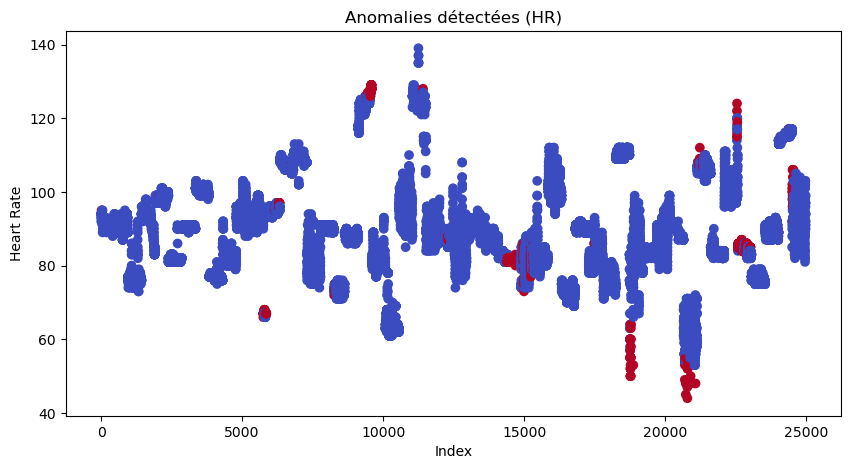

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(df.index, df['HR'], c=df['anomaly_label'], cmap='coolwarm')
plt.title("Anomalies détectées (HR)")
plt.xlabel("Index")
plt.ylabel("Heart Rate")
plt.show()

## Exemple de test

In [44]:
normal_sample = [[72, 16, 98]]  # HR, RR, SpO2
anomaly_sample = [[115, 28, 90]]

# Normalisation avec le même scaler
normal_scaled = scaler.transform(normal_sample)
anomaly_scaled = scaler.transform(anomaly_sample)

# Prédiction
print("Normal sample:", model.predict(normal_scaled))
print("Anomaly sample:", model.predict(anomaly_scaled))

# Score
print("Normal score:", model.decision_function(normal_scaled))
print("Anomaly score:", model.decision_function(anomaly_scaled))

Normal sample: [1]
Anomaly sample: [-1]
Normal score: [0.13723158]
Anomaly score: [-0.11834603]


C:\Users\wiame\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\wiame\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
